In [246]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [247]:
import torch

In [248]:
torch.__version__

'2.7.1+cu118'

In [249]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [250]:
from pathlib import Path

In [251]:
img_path = Path("data/pizza_steak_sushi")

In [252]:
img_path

WindowsPath('data/pizza_steak_sushi')

In [253]:
train_dir = img_path / "train"
test_dir = img_path / "test"

In [254]:
img_list = list(img_path.glob("*/*/*.jpg"))
img_list

[WindowsPath('data/pizza_steak_sushi/test/pizza/1152100.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1503858.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1687143.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1925494.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/194643.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/195160.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2003290.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2111981.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2124579.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2218680.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2236338.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2508636.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2871261.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/3092704.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/309892.jp

In [255]:
len(img_list)

300

In [256]:
import random as r
a = r.choice(img_list)
a

WindowsPath('data/pizza_steak_sushi/train/steak/2254705.jpg')

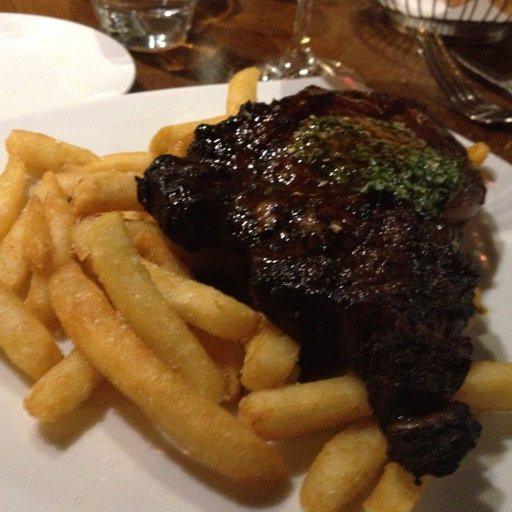

In [257]:
from PIL import Image
Image.open(a)

In [258]:
from torchvision import transforms

In [259]:
t = transforms.ToTensor()

In [260]:
import os
for dirpath , dirname , filenames in os.walk(img_path):
    print(f"path = {dirpath} , dirname = {dirname} , len of folder = {len(dirname)} , files = {filenames} , len of file = {len(filenames)}")

path = data\pizza_steak_sushi , dirname = ['test', 'train'] , len of folder = 2 , files = [] , len of file = 0
path = data\pizza_steak_sushi\test , dirname = ['pizza', 'steak', 'sushi'] , len of folder = 3 , files = [] , len of file = 0
path = data\pizza_steak_sushi\test\pizza , dirname = [] , len of folder = 0 , files = ['1152100.jpg', '1503858.jpg', '1687143.jpg', '1925494.jpg', '194643.jpg', '195160.jpg', '2003290.jpg', '2019408.jpg', '2111981.jpg', '2124579.jpg', '2218680.jpg', '2236338.jpg', '2508636.jpg', '2871261.jpg', '3092704.jpg', '309892.jpg', '344397.jpg', '3475871.jpg', '398345.jpg', '416067.jpg', '540882.jpg', '648055.jpg', '714866.jpg', '930553.jpg', '971934.jpg'] , len of file = 25
path = data\pizza_steak_sushi\test\steak , dirname = [] , len of folder = 0 , files = ['100274.jpg', '1016217.jpg', '1285886.jpg', '1302563.jpg', '1627703.jpg', '1868005.jpg', '1882831.jpg', '2117351.jpg', '2144308.jpg', '27415.jpg', '296375.jpg', '3424937.jpg', '354513.jpg', '3873283.jpg', '

In [261]:
import os
for dirpath , dirname , filenames in os.walk(img_path):
    print(f"path = {dirpath} ,  len of folder = {len(dirname)} , len of file = {len(filenames)}")

path = data\pizza_steak_sushi ,  len of folder = 2 , len of file = 0
path = data\pizza_steak_sushi\test ,  len of folder = 3 , len of file = 0
path = data\pizza_steak_sushi\test\pizza ,  len of folder = 0 , len of file = 25
path = data\pizza_steak_sushi\test\steak ,  len of folder = 0 , len of file = 19
path = data\pizza_steak_sushi\test\sushi ,  len of folder = 0 , len of file = 31
path = data\pizza_steak_sushi\train ,  len of folder = 3 , len of file = 0
path = data\pizza_steak_sushi\train\pizza ,  len of folder = 0 , len of file = 78
path = data\pizza_steak_sushi\train\steak ,  len of folder = 0 , len of file = 75
path = data\pizza_steak_sushi\train\sushi ,  len of folder = 0 , len of file = 72


In [262]:
from torchvision import datasets , transforms
from torch.utils.data import DataLoader
data_trans = transforms.Compose([transforms.Resize((64,64)) , transforms.RandomHorizontalFlip(p = 0.5) , transforms.ToTensor()])

In [263]:
t_train = datasets.ImageFolder(root = train_dir , transform = data_trans , target_transform = None)
t_test = datasets.ImageFolder(root = test_dir , transform = data_trans , target_transform = None)

In [264]:
len(t_train) , type(t_train)

(225, torchvision.datasets.folder.ImageFolder)

In [265]:
classes = t_train.classes

In [266]:
classes

['pizza', 'steak', 'sushi']

In [267]:
t_train.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [268]:
img , lab = t_train[0][0] , t_train[0][1]

In [269]:
img.shape

torch.Size([3, 64, 64])

In [270]:
import matplotlib.pyplot as plt

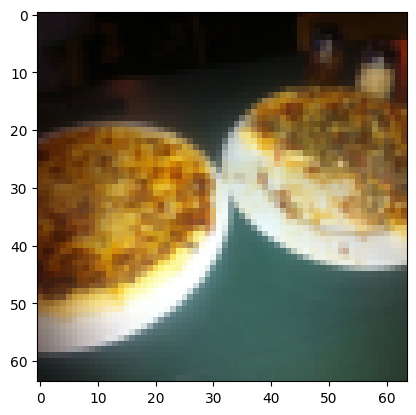

In [271]:
plt.imshow(img.permute(1,2,0))

In [272]:
high_pixel = transforms.Compose([transforms.Resize((1000,1000))])
n = high_pixel(img)

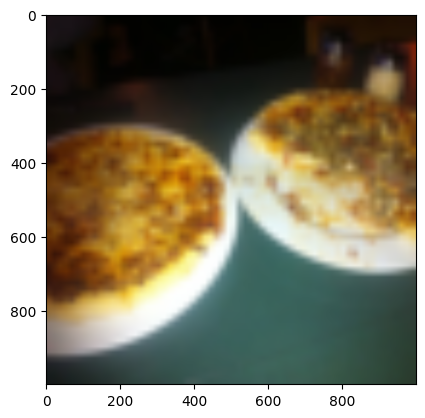

In [273]:
plt.imshow(n.permute(1,2,0))

## transformed data = t_train and t_test

In [274]:
from torch.utils.data import DataLoader
train_batch = 32
train_stack = DataLoader(dataset = t_train , batch_size = train_batch , shuffle = True)
test_stack = DataLoader(dataset = t_test , batch_size = train_batch , shuffle = True)

In [275]:
len(train_stack)

8

In [276]:
img , lab = next(iter(train_stack))
img

tensor([[[[0.0510, 0.0510, 0.0510,  ..., 0.0157, 0.0196, 0.0157],
          [0.0863, 0.0941, 0.0980,  ..., 0.0196, 0.0196, 0.0157],
          [0.0275, 0.0314, 0.0314,  ..., 0.0196, 0.0196, 0.0196],
          ...,
          [0.5176, 0.5333, 0.5490,  ..., 0.6118, 0.5961, 0.5843],
          [0.5176, 0.5294, 0.5451,  ..., 0.5922, 0.5765, 0.5647],
          [0.5020, 0.5137, 0.5333,  ..., 0.5647, 0.5529, 0.5373]],

         [[0.0431, 0.0431, 0.0431,  ..., 0.0157, 0.0196, 0.0157],
          [0.0784, 0.0863, 0.0941,  ..., 0.0196, 0.0157, 0.0157],
          [0.0235, 0.0275, 0.0314,  ..., 0.0157, 0.0157, 0.0157],
          ...,
          [0.5333, 0.5451, 0.5569,  ..., 0.5843, 0.5686, 0.5529],
          [0.5216, 0.5333, 0.5451,  ..., 0.5608, 0.5451, 0.5255],
          [0.5176, 0.5255, 0.5373,  ..., 0.5451, 0.5216, 0.5020]],

         [[0.0549, 0.0549, 0.0588,  ..., 0.0157, 0.0196, 0.0157],
          [0.0902, 0.0980, 0.1059,  ..., 0.0196, 0.0196, 0.0157],
          [0.0275, 0.0314, 0.0314,  ..., 0

In [277]:
img.shape

torch.Size([32, 3, 64, 64])

In [278]:
f = img[0]

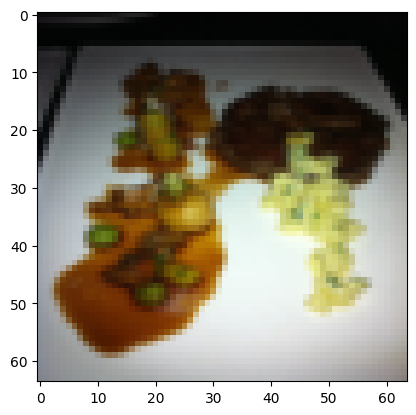

In [279]:
plt.imshow(f.permute(1,2,0))

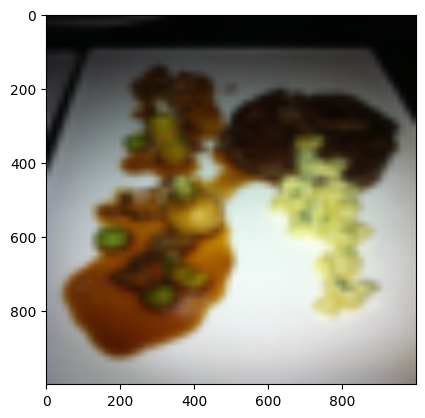

In [280]:
j = high_pixel(f)
plt.imshow(j.permute(1,2,0))

## making augmented data

In [281]:
aug_t = transforms.Compose([transforms.Resize((224,224)) , transforms.TrivialAugmentWide(num_magnitude_bins = 27) , transforms.ToTensor() , transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )])
simple_aug = transforms.Compose([transforms.Resize((224,224)) ,transforms.ToTensor() , transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )])

In [282]:
train_aug = datasets.ImageFolder(root = train_dir , target_transform = None , transform = aug_t )
test_aug = datasets.ImageFolder(root = test_dir , transform = simple_aug )

In [283]:
train_dl = DataLoader(dataset = train_aug , shuffle = True , batch_size = train_batch)
test_dl = DataLoader(dataset = test_aug , shuffle = True , batch_size = train_batch)

In [284]:
img , lab = next(iter(train_dl))

In [285]:
img.shape

torch.Size([32, 3, 224, 224])

In [286]:
x = img[0]

In [287]:
x.shape

torch.Size([3, 224, 224])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9481792..0.77507645].


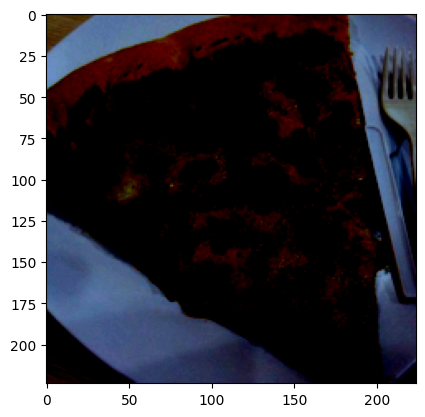

In [288]:
plt.imshow(x.permute(1,2,0))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9465196..0.7750765].


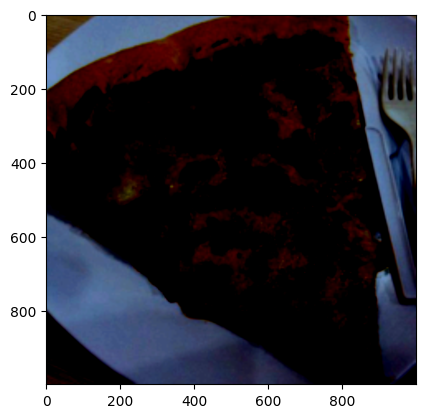

In [289]:
y = high_pixel(x)
plt.imshow(y.permute(1,2,0))

In [290]:
import numpy as np

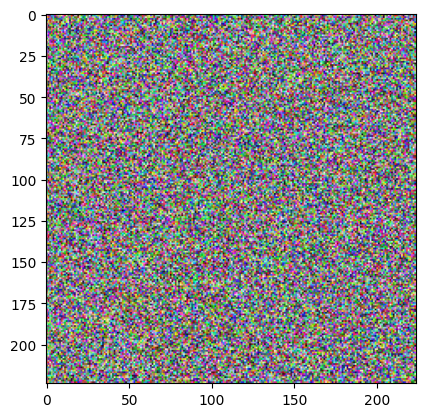

In [291]:
arr = np.random.rand(224, 224, 3)
plt.imshow(arr)

## so dataloader is train_dl and test_dl

In [292]:
import torch.nn as nn

In [293]:
class tvg(nn.Module):
    def __init__(self, input_feature: int, hidden_feature: int, output_feature: int):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(input_feature, hidden_feature, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(hidden_feature, hidden_feature, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(hidden_feature, hidden_feature, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(hidden_feature, hidden_feature, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(hidden_feature, output_feature)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.block2(self.block1(x)))

In [294]:
mo = tvg(input_feature = 3 , hidden_feature = 16 , output_feature = len(classes))
mo.state_dict()

OrderedDict([('block1.0.weight',
              tensor([[[[-2.6013e-02,  1.4333e-01, -1.2898e-01],
                        [-9.4442e-02,  4.0405e-02, -7.4620e-02],
                        [ 7.5185e-02, -6.7013e-02,  1.5287e-01]],
              
                       [[-1.8542e-01, -7.3274e-02, -1.8667e-01],
                        [-1.6684e-01, -1.5685e-01, -6.0587e-02],
                        [-1.2818e-01, -5.4767e-02,  1.6369e-01]],
              
                       [[-1.8799e-01, -8.9760e-02,  1.7534e-01],
                        [ 7.2632e-02,  1.0935e-01,  1.2641e-01],
                        [-1.5618e-01,  1.6869e-01, -1.0348e-01]]],
              
              
                      [[[ 1.6862e-01,  1.7487e-01,  4.1604e-02],
                        [-4.4953e-03, -4.7889e-02,  2.0788e-02],
                        [ 4.3161e-02,  1.4172e-01,  1.6662e-01]],
              
                       [[-6.1008e-02,  1.4462e-01, -1.1742e-01],
                        [ 1.8075e-01, -5.9

In [295]:
loss_fn = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(params = mo.parameters() , lr = 0.0001)

In [296]:
from torchmetrics import Accuracy
acc_fn = Accuracy(task = "multiclass" , num_classes=len(classes) ).to(device)

In [297]:
def train_step(accuracy_fn ,model : torch.nn.Module , dataloader : torch.utils.data.DataLoader , loss_fn : torch.nn.Module , optimizer : torch.optim.Optimizer
              ):
    model.train()
    model.to(device)
    train_loss , train_acc = 0 , 0
    for batch , (x,y) in enumerate(dataloader):
        x , y = x.to(device) , y.to(device)
        y_pred = model(x)
        loss = loss_fn(y_pred , y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = torch.argmax(y_pred, dim=1)
        train_acc += accuracy_fn(y_pred_class, y)
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    return train_loss, train_acc

In [298]:
def test_step(accuracy_fn ,model : torch.nn.Module , dataloader : torch.utils.data.DataLoader , loss_fn : torch.nn.Module 
               ):
    model.eval()
    model.to(device)
    with torch.inference_mode():
        test_loss , test_acc = 0 , 0
        for batch , (x,y) in enumerate(dataloader):
            x , y = x.to(device) , y.to(device)
            y_pred = model(x)
            loss = loss_fn(y_pred , y)
            test_loss += loss.item()
            y_pred_class = torch.argmax(y_pred, dim=1)
            test_acc += accuracy_fn(y_pred_class, y)
        test_loss /= len(dataloader)
        test_acc /= len(dataloader)
    return test_loss, test_acc

In [299]:
mo.state_dict()

OrderedDict([('block1.0.weight',
              tensor([[[[-2.6013e-02,  1.4333e-01, -1.2898e-01],
                        [-9.4442e-02,  4.0405e-02, -7.4620e-02],
                        [ 7.5185e-02, -6.7013e-02,  1.5287e-01]],
              
                       [[-1.8542e-01, -7.3274e-02, -1.8667e-01],
                        [-1.6684e-01, -1.5685e-01, -6.0587e-02],
                        [-1.2818e-01, -5.4767e-02,  1.6369e-01]],
              
                       [[-1.8799e-01, -8.9760e-02,  1.7534e-01],
                        [ 7.2632e-02,  1.0935e-01,  1.2641e-01],
                        [-1.5618e-01,  1.6869e-01, -1.0348e-01]]],
              
              
                      [[[ 1.6862e-01,  1.7487e-01,  4.1604e-02],
                        [-4.4953e-03, -4.7889e-02,  2.0788e-02],
                        [ 4.3161e-02,  1.4172e-01,  1.6662e-01]],
              
                       [[-6.1008e-02,  1.4462e-01, -1.1742e-01],
                        [ 1.8075e-01, -5.9

## train_step(accuracy_fn ,model : torch.nn.Module , dataloader : torch.utils.data.DataLoader , loss_fn : torch.nn.Module , optimizer : torch.optim.Optimizer )

In [300]:
len(train_dl) , len(train_stack)

(8, 8)

In [301]:
from tqdm.auto import tqdm
epochs = 3
for epoch in tqdm(range(epochs)):
    v1 , v2 = train_step(acc_fn , model = mo , dataloader = train_dl , loss_fn = loss_fn , optimizer = optimizer )
    print(f"epoch = {epoch} avg train loss = {v1} avg train accuracy  = {v2}")
    w1 , w2 = test_step(acc_fn , model = mo , dataloader = test_dl , loss_fn = loss_fn)
    print(f"epoch = {epoch} avg test loss = {w1} avg test accuracy  = {w2}\n\n")

  0%|          | 0/3 [00:00<?, ?it/s]

epoch = 0 avg train loss = 1.093979388475418 avg train accuracy  = 0.40234375
epoch = 0 avg test loss = 1.0899219115575154 avg test accuracy  = 0.38257575035095215


epoch = 1 avg train loss = 1.1386285424232483 avg train accuracy  = 0.28125
epoch = 1 avg test loss = 1.096480170885722 avg test accuracy  = 0.4223484992980957


epoch = 2 avg train loss = 1.1371827274560928 avg train accuracy  = 0.28125
epoch = 2 avg test loss = 1.0846127271652222 avg test accuracy  = 0.38257575035095215




In [302]:
mo = tvg(input_feature = 3 , hidden_feature = 32 , output_feature = len(classes))

In [303]:
a = torch.optim.SGD(params = mo.parameters() , lr = 0.0003)

In [304]:
from tqdm.auto import tqdm
epochs = 3
for epoch in tqdm(range(epochs)):
    v1 , v2 = train_step(acc_fn , model = mo , dataloader = train_dl , loss_fn = loss_fn , optimizer = a )
    print(f"epoch = {epoch} avg train loss = {v1} avg train accuracy  = {v2}")
    w1 , w2 = test_step(acc_fn , model = mo , dataloader = test_dl , loss_fn = loss_fn)
    print(f"epoch = {epoch} avg test loss = {w1} avg test accuracy  = {w2}\n\n")

  0%|          | 0/3 [00:00<?, ?it/s]

epoch = 0 avg train loss = 1.0971291065216064 avg train accuracy  = 0.40234375
epoch = 0 avg test loss = 1.098170240720113 avg test accuracy  = 0.4223484992980957


epoch = 1 avg train loss = 1.0992210656404495 avg train accuracy  = 0.27734375
epoch = 1 avg test loss = 1.0980935494105022 avg test accuracy  = 0.4024621248245239


epoch = 2 avg train loss = 1.096693828701973 avg train accuracy  = 0.40234375
epoch = 2 avg test loss = 1.0971258481343586 avg test accuracy  = 0.4422348439693451




# we will use transfer learning as accuracy is still low

In [306]:
from torchvision import transforms
t = transforms.Compose([transforms.Resize((224,224)) , transforms.ToTensor() , transforms.Normalize(mean = [0.485 , 0.456 , 0.406] , std = [0.224 , 0.224 ,0.225])])

In [309]:
img_path

WindowsPath('data/pizza_steak_sushi')

In [311]:
train_dir , test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

In [312]:
from torchvision import datasets
x_train = datasets.ImageFolder(root = train_dir , transform = t , target_transform = None)
x_test =  datasets.ImageFolder(root = test_dir , transform = t , target_transform = None)

In [313]:
from torch.utils.data import DataLoader
train_f = DataLoader(dataset = x_train , shuffle = True , batch_size = 32)
test_f = DataLoader(dataset = x_test , shuffle = True , batch_size = 32)

In [314]:
img , lab = next(iter(test_f))
img

tensor([[[[ 1.1436,  1.2487,  1.3537,  ...,  1.6689,  1.6163,  1.5638],
          [ 1.2312,  1.3187,  1.3887,  ...,  1.6864,  1.6163,  1.5813],
          [ 1.2662,  1.3712,  1.4238,  ...,  1.6513,  1.5988,  1.5813],
          ...,
          [ 1.0211,  0.9861,  1.0036,  ...,  0.9336,  0.8810,  0.8285],
          [ 0.9686,  0.9686,  0.9686,  ...,  0.9336,  0.8985,  0.8285],
          [ 0.9511,  0.9861,  0.9686,  ...,  0.9686,  0.8810,  0.8110]],

         [[ 1.0105,  1.0280,  1.1155,  ...,  1.5882,  1.5357,  1.4657],
          [ 1.1155,  1.1155,  1.1506,  ...,  1.6057,  1.5357,  1.4832],
          [ 1.1681,  1.1856,  1.1856,  ...,  1.5882,  1.5182,  1.5182],
          ...,
          [ 0.8004,  0.7654,  0.8004,  ...,  0.9230,  0.8704,  0.8529],
          [ 0.7479,  0.7479,  0.7654,  ...,  0.9230,  0.8880,  0.8529],
          [ 0.7304,  0.7479,  0.7654,  ...,  0.9580,  0.8880,  0.8354]],

         [[ 0.9145,  0.8622,  0.9145,  ...,  1.3851,  1.3851,  1.3502],
          [ 1.0017,  0.9494,  

In [315]:
img.shape

torch.Size([32, 3, 224, 224])

In [321]:
img[1].shape

torch.Size([3, 224, 224])

In [322]:
b = img[1]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1651785..2.64].


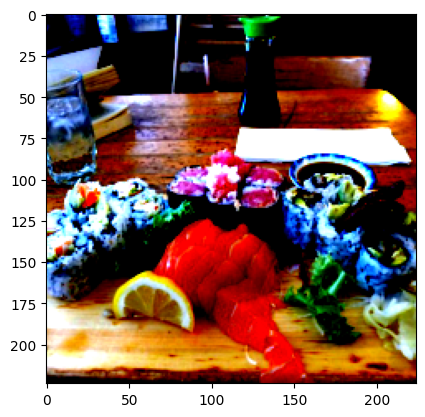

In [323]:
plt.imshow(b.permute(1,2,0))

In [325]:
import torchvision

In [329]:
weight = torchvision.models.EfficientNet_B0_Weights.DEFAULT

In [330]:
weight

EfficientNet_B0_Weights.IMAGENET1K_V1

In [332]:
auto_trans = weight.transforms()
auto_trans

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [333]:
train_stack = datasets.ImageFolder(root = train_dir , transform = auto_trans , target_transform = None )
test_stack = datasets.ImageFolder(root = test_dir , transform = auto_trans , target_transform = None)

In [334]:
trainD = DataLoader(dataset = train_stack , batch_size = 32 , shuffle = True)
testD = DataLoader(dataset = test_stack , batch_size = 32 , shuffle = True)

In [335]:
mo = torchvision.models.efficientnet_b0(weights=weight).to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\divyadarshee dash/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|█████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:02<00:00, 8.71MB/s]


In [338]:
classes = train_stack.classes

In [340]:
!pip install torchinfo

In [348]:
from torchinfo import summary
summary(mo, input_size=(32, 3, 255,255))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [32, 1000]                --
├─Sequential: 1-1                                       [32, 1280, 8, 8]          --
│    └─Conv2dNormActivation: 2-1                        [32, 32, 128, 128]        --
│    │    └─Conv2d: 3-1                                 [32, 32, 128, 128]        864
│    │    └─BatchNorm2d: 3-2                            [32, 32, 128, 128]        64
│    │    └─SiLU: 3-3                                   [32, 32, 128, 128]        --
│    └─Sequential: 2-2                                  [32, 16, 128, 128]        --
│    │    └─MBConv: 3-4                                 [32, 16, 128, 128]        1,448
│    └─Sequential: 2-3                                  [32, 24, 64, 64]          --
│    │    └─MBConv: 3-5                                 [32, 24, 64, 64]          6,004
│    │    └─MBConv: 3-6                              

In [353]:
in_features = mo.classifier[1].in_features
mo.classifier = torch.nn.Sequential(torch.nn.Dropout(p=0.2, inplace=True),torch.nn.Linear(in_features=in_features, out_features=len(classes))).to(device)

In [358]:
loss_fn = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(mo.parameters(), lr=0.001)

In [362]:
acc_fn = Accuracy(task = "multiclass" , num_classes = len(classes)).to(device)

In [363]:
epochs = 10
for epoch in tqdm(range(epochs)):
    v1 , v2 = train_step(acc_fn , model = mo , dataloader = trainD , loss_fn = loss_fn , optimizer = optimizer )
    print(f"epoch = {epoch} avg train loss = {v1} avg train accuracy  = {v2}")
    w1 , w2 = test_step(acc_fn , model = mo , dataloader = testD , loss_fn = loss_fn)
    print(f"epoch = {epoch} avg test loss = {w1} avg test accuracy  = {w2}\n\n")
    

  0%|          | 0/10 [00:00<?, ?it/s]

epoch = 0 avg train loss = 0.5137501675635576 avg train accuracy  = 0.7734375
epoch = 0 avg test loss = 0.5706181228160858 avg test accuracy  = 0.8759469985961914


epoch = 1 avg train loss = 0.3035952867940068 avg train accuracy  = 0.83984375
epoch = 1 avg test loss = 0.15876581768194833 avg test accuracy  = 0.948863685131073


epoch = 2 avg train loss = 0.22857110435143113 avg train accuracy  = 0.86328125
epoch = 2 avg test loss = 0.16880559921264648 avg test accuracy  = 0.948863685131073


epoch = 3 avg train loss = 0.08102994319051504 avg train accuracy  = 0.99609375
epoch = 3 avg test loss = 0.28640010207891464 avg test accuracy  = 0.9592803716659546


epoch = 4 avg train loss = 0.07048690936062485 avg train accuracy  = 0.98828125
epoch = 4 avg test loss = 0.5060295214255651 avg test accuracy  = 0.8977272510528564


epoch = 5 avg train loss = 0.3820679104537703 avg train accuracy  = 0.87109375
epoch = 5 avg test loss = 0.3110339691241582 avg test accuracy  = 0.9583333730697632


e

## up code output seems at epoch 3 we get best output

In [368]:
path = Path("models")
model_name = "efficient_net_B0.pth"
model_save_path = path / model_name
torch.save(obj = mo.state_dict() , f = model_save_path)

In [369]:
load_mo = torchvision.models.efficientnet_b0().to(device)

In [398]:
load_mo.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280, out_features=3)
).to(device)

## predicting on tester folder

In [415]:
img_path

WindowsPath('data/pizza_steak_sushi')

In [416]:
tester_dir = Path("testing")

In [417]:
tester_list = list(tester_dir.glob("*.jpg"))

In [418]:
tester_list

[WindowsPath('testing/download (1).jpg'),
 WindowsPath('testing/download (2).jpg'),
 WindowsPath('testing/download.jpg')]

In [424]:
i1 = tester_list[0]
i2 = tester_list[1]
i3 = tester_list[2]

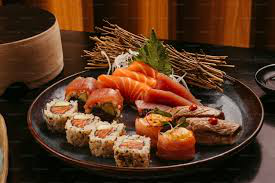

In [425]:
Image.open(i1)

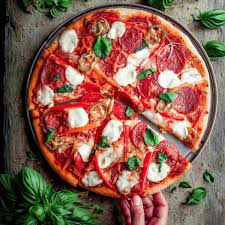

In [427]:
Image.open(i2)

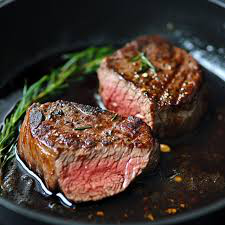

In [429]:
Image.open(i3)

In [431]:
tester_ = datasets.ImageFolder(root = tester_dir , transform = auto_trans , target_transform = None)
data = DataLoader(dataset = tester_ , batch_size = 1 , shuffle = True)

In [432]:
tester_.classes

['pizza', 'steak', 'sushi']

In [434]:
tester_.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [438]:
for batch , (x,y) in enumerate(data):
    print(x.shape)

torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])


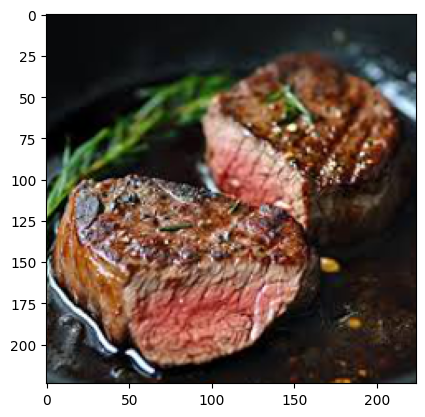

steak


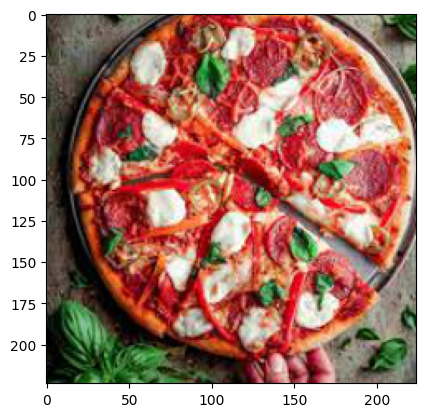

Pizza


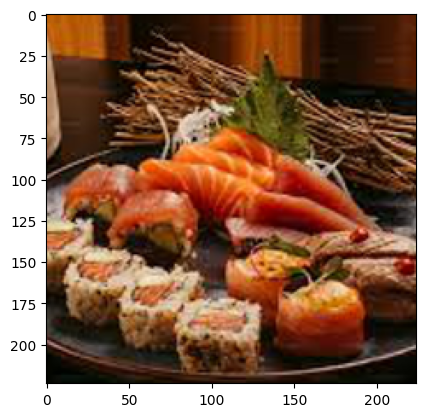

sushi


In [447]:
mo.eval()
mo.to(device)

mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

with torch.inference_mode():
    for batch , (x,y) in enumerate(data):
        x,y = x.to(device) , y.to(device)
        img = x.squeeze().cpu().permute(1,2,0)
        img = img * std + mean
        img = img.clamp(0,1)
        plt.imshow(img)
        plt.show()
        y_pred = mo(x)
        classes = torch.argmax(y_pred, dim=1).item()

        if classes == 0:
            print("Pizza")
        elif classes == 1:
            print("steak")
        elif classes == 2:
            print("sushi")
        else:
            print("unable to get")